Neural Network

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Step 2: Create Dataset

In [ ]:
data = {

'StudyHours':[2,3,4,5,6,7,8,4,9,10],

'Attendance':[60,65,70,75,80,85,90,68,95,98],

'Assignment':[55,58,65,70,75,80,88,63,92,96],

'Pass':[0,0,0,1,1,1,1,0,1,1]

}

df = pd.DataFrame(data)

df

,StudyHours,Attendance,Assignment,Pass
0,2,60,55,0
1,3,65,58,0
2,4,70,65,0
3,5,75,70,1
4,6,80,75,1
5,7,85,80,1
6,8,90,88,1
7,4,68,63,0
8,9,95,92,1
9,10,98,96,1


Step 3: Split Input and Output

In [ ]:
X = df[['StudyHours','Attendance','Assignment']]

y = df['Pass']

Step 4: Feature Scaling

In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

Step 5: Train-Test Split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

Step 6: Build Deep Neural Network

In [ ]:
model = Sequential()

model.add(Dense(8,
                activation='relu',
                input_shape=(3,)))

model.add(Dense(4,
                activation='relu'))

model.add(Dense(1,
                activation='sigmoid'))

Step 7: Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Step 8: Train Model

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=2,
    validation_split=0.20
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.5000 - loss: 21.2521 - val_accuracy: 0.0000e+00 - val_loss: 38.7734
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5000 - loss: 20.3074 - val_accuracy: 0.0000e+00 - val_loss: 37.5529
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5000 - loss: 19.7154 - val_accuracy: 0.0000e+00 - val_loss: 36.1225
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5000 - loss: 18.9435 - val_accuracy: 0.0000e+00 - val_loss: 34.6451
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5000 - loss: 18.0287 - val_accuracy: 0.0000e+00 - val_loss: 33.2516
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5000 - loss: 17.3028 - val_accuracy: 0.0000e+00 - val_loss: 31.8700
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5000 - loss: 16.5602 - val_accuracy: 0.0000e+00 - val_loss: 30.5109
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5000 - loss:

Step 9: Evaluate

In [ ]:
loss,accuracy = model.evaluate(X_test,y_test)

print("Accuracy :",accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 1.0000 - loss: 0.0721
Accuracy : 1.0


Step 10: Prediction

In [ ]:
new_student = [[6,85,78]]

new_student = scaler.transform(new_student)

prediction = model.predict(new_student)

print(prediction)

if prediction>=0.5:
    print("Pass")
else:
    print("Fail")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
[[0.84106886]]
Pass


Deep Neural Network (DNN) for Diabetes Prediction

Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Step 2: Upload Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


Step 3: Load Dataset

In [ ]:
df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Step 4: Understand Dataset

In [ ]:
df.shape

(769, 9)

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 769 entries, 0 to 768
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               769 non-null    int64  
 1   Glucose                   769 non-null    int64  
 2   BloodPressure             769 non-null    int64  
 3   SkinThickness             769 non-null    int64  
 4   Insulin                   769 non-null    int64  
 5   BMI                       769 non-null    float64
 6   DiabetesPedigreeFunction  769 non-null    float64
 7   Age                       769 non-null    int64  
 8   Outcome                   769 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.2 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000
mean,3.841352,120.858257,69.106632,20.550065,79.695709,31.990507,0.471672,33.227568,0.348505
std,3.368946,31.967626,19.343229,15.946293,115.204894,7.879235,0.331161,11.758373,0.476807
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,29.000000,32.000000,0.371000,29.000000,0.000000
75%,6.000000,140.000000,80.000000,32.000000,127.000000,36.600000,0.626000,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Step 5: Check Missing Values

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Step 6: Data Cleaning

In [ ]:
columns = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

df[columns] = df[columns].replace(0,np.nan)

Fill missing values using the median.

In [ ]:
for col in columns:
    df[col] = df[col].fillna(df[col].median())

Verify missing values.

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Step 7: Exploratory Data Analysis (EDA)

Class Distribution

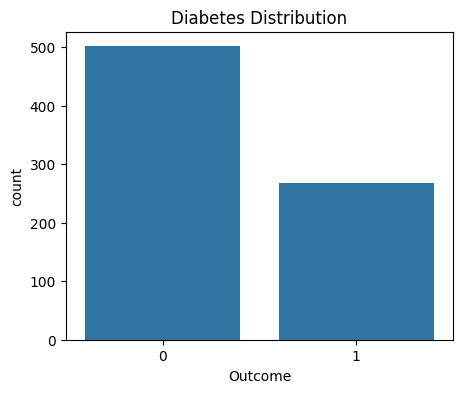

In [ ]:
plt.figure(figsize=(5,4))

sns.countplot(x='Outcome',data=df)

plt.title("Diabetes Distribution")

plt.show()

Step 8: Feature Selection

In [ ]:
X = df.drop("Outcome",axis=1)

y = df["Outcome"]

Step 9: Feature Scaling

In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

Step 10: Train-Test Split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

Step 11: Build Deep Neural Network

In [ ]:
model = Sequential()

Input Layer + Hidden Layer 1

In [ ]:
model.add(Dense(
    16,
    activation='relu',
    input_shape=(8,)
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Hidden Layer 2

In [ ]:
model.add(Dense(
    8,
    activation='relu'
))

Hidden Layer 3

In [ ]:
model.add(Dense(
    4,
    activation='relu'
))

Output Layer

In [ ]:
model.add(Dense(
    1,
    activation='sigmoid'
))

Step 12: View Model Architecture

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

Step 13: Compile the Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.20
)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3496 - loss: 0.7570 - val_accuracy: 0.4553 - val_loss: 0.7165
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5732 - loss: 0.6964 - val_accuracy: 0.5691 - val_loss: 0.6944
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6484 - loss: 0.6826 - val_accuracy: 0.5854 - val_loss: 0.6868
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6890 - loss: 0.6737 - val_accuracy: 0.6260 - val_loss: 0.6777
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6992 - loss: 0.6624 - val_accuracy: 0.6585 - val_loss: 0.6652
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7154 - loss: 0.6476 - val_accuracy: 0.6829 - val_loss: 0.6443
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7093 - loss: 0.6250 - val_accuracy: 0.7073 - val_loss: 0.6131
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7276 - loss: 0.5920 - val_accuracy: 0.7236 - 

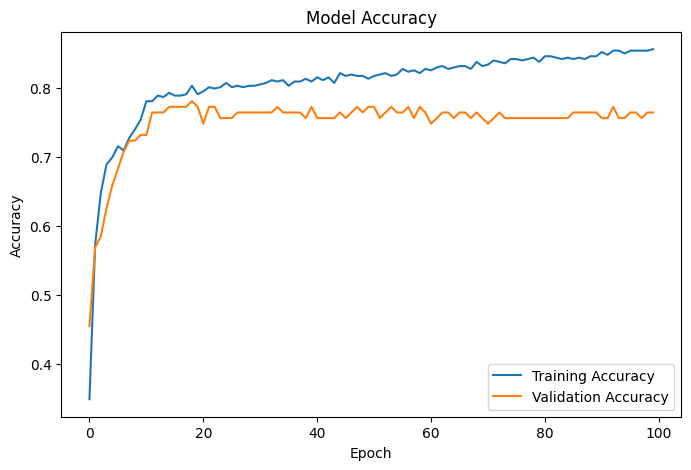

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Model Accuracy")

plt.legend()

plt.show()

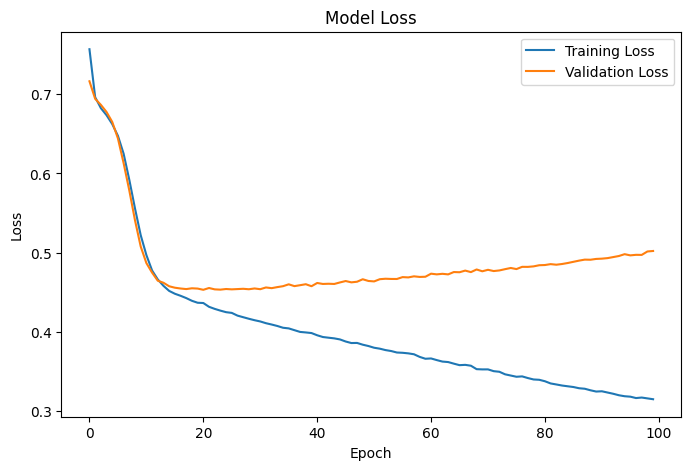

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Model Loss")

plt.legend()

plt.show()

In [ ]:
loss,accuracy = model.evaluate(
    X_test,
    y_test
)

print("Loss :",loss)

print("Accuracy :",accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7078 - loss: 0.6148 
Loss : 0.6148183941841125
Accuracy : 0.7077922224998474


In [ ]:
prediction = model.predict(X_test)

prediction = (prediction>0.5).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


In [ ]:
accuracy = accuracy_score(
    y_test,
    prediction
)

print("Accuracy =",accuracy)

Accuracy = 0.7077922077922078


In [ ]:
cm = confusion_matrix(
    y_test,
    prediction
)

print(cm)

[[71 29]
 [16 38]]


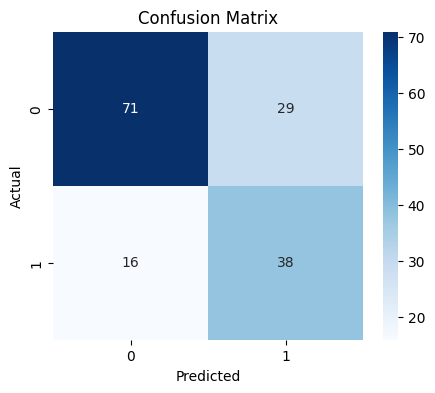

In [ ]:
plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(
    y_test,
    prediction
))

              precision    recall  f1-score   support

           0       0.82      0.71      0.76       100
           1       0.57      0.70      0.63        54

    accuracy                           0.71       154
   macro avg       0.69      0.71      0.69       154
weighted avg       0.73      0.71      0.71       154



In [ ]:
new_patient = [[
    2,
    20,
    60,
    30,
    100,
    28,
    0.50,
    35
]]

new_patient = scaler.transform(new_patient)

prediction = model.predict(new_patient)

print(prediction)

if prediction>=0.5:
    print("Diabetes")
else:
    print("No Diabetes")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
[[0.00036142]]
No Diabetes


              Diabetes Dataset
                     │
                     ▼
              Data Preprocessing
                     │
                     ▼
            Feature Selection (8)
                     │
                     ▼
             Standardization
                     │
                     ▼
             Train-Test Split
                     │
                     ▼
             Input Layer (8)
                     │
                     ▼
        Hidden Layer 1 (16 Neurons)
             Activation: ReLU
                     │
                     ▼
         Hidden Layer 2 (8 Neurons)
             Activation: ReLU
                     │
                     ▼
         Hidden Layer 3 (4 Neurons)
             Activation: ReLU
                     │
                     ▼
          Output Layer (1 Neuron)
          Activation: Sigmoid
                     │
                     ▼
          Diabetes Prediction
              0 = No Diabetes
              1 = Diabetes